# Descriptive Statistics - Numerical Measures

## 1 Measures of location (central tendency)

### 1.1 Formulas for measures of location
### Mean
Perhaps the most important measure of location is the **mean**, or average value, for a variable. If the data are for a sample, the mean is denoted by $\bar{x}$; if the data are for a population, the mean is denoted by the Greek letter $\mu$.

> $$\bar{x}=\frac{\sum x_i}{n}$$

### Weighted Mean
In the formulas for the sample mean and population mean, each $x_i$ is given equal importance or weight. For example mean can be written as follows:
$$\bar{x}=\frac{\sum x_i}{n}=\frac{1}{n}(x_1)+\frac{1}{n}(x_2)+...+\frac{1}{n}(x_n)$$
This shows that each observation in the sample is given a weight of 1/n. Although this practice is most common, in some instances the mean is computed by giving each observation a weight that reflects its relative importance. A mean computed in this manner is referred to as a **weighted mean**.

> $$\bar{x}=\frac{\sum w_ix_i}{\sum w_i}$$
  where
  $w_i$ = weight for observation i.
  
**Weighted estimators** may be necessary if the goal of the sample analysis is prediction of population behavior. Suppose we have a sample collected by survey of the population of interest (microeconometrics reasearch data are usually collected in such a way), and each household has a probability $\pi_i$ of appreaing in the sample. If the sampling method is SRS (simple random sampling), $\pi_i$ would be the same for all household so that it can ignored. But let's assume that, unlike SRS, this probability varies across households.

Then the sample mean that give equal weight to all observations will tend to give too much weight to households that appear with high probability in the sample. This bias can be corrected by using the **inverse probability weight**.

$$w_i = 1/\pi_i$$

And with the weighted mean, the sample mean would be an unbiased estimator of the population mean.

### Geometric Mean
The **geometric mean** is a measure of location that is calculated by finding the *nth* root of the product of *n* values. The general formula for the geometric mean, denoted $\bar{x}_g$, follows.

> $$\bar{x}_g=\sqrt[n]{\Pi x_i} = [(x_1)(x_2)...(x_n)]^{1/n}$$

Note that $x_i$ in the formula are known as the **growth factor**. It should be a ratio comparing the current value to the value in the previous period. This means that if you starts with some monetary values $p_t$, you should first calculate the growth factor by using $x_t = p_t/p_{t-1}$.

Also note that $x_i$ is not the growth rate. Indeed,

$$\text{growth factor}=(1 + \text{growth rate})$$

The geometric mean is often used in analyzing financial data.

### Median
The **median** is another measure of central location. The median is the value in the middle when the data are arranged in ascending order (smallest value to largest value). With an odd number of observations, the median is the middle value. An even number of observation has no single middle value. In this case, we follow convention and define the median as the average of the values for the middle two observations.

Although the mean is the more commonly used measure of central location, in some situations the median is preferred. For example, the median is intact of the existence of extreme values, which provides a better measure of central location than the mean. We can generalize to say that whenever a data set contains extreme values, the median is often the preferred measure of central location.

### Mode

The mode is the value that occurs with greatest frequency

### Percentiles

A **percentile** or **quantile** provides information about how the data are spread over the interval from the samllest value to the largest value. For a data set containin n observations, the **pth percentile** divides the data into two parts: approximately p% of the observations are less htan the pth percentile, and approximately (100-p)% of the observations are greater than the pth percentile.

> Step 1: Sort the data from smallest to largest <br/>
Step 2: Calculate the location of the pth percentile $$L_p = (\frac{p}{100})(n+1)$$
Step 3: If $L_p$ is an integer, the pth percentile is the the number at location $L_p$ <br/>
If $L_p$ a fraction, locate the two adjecent numbers $x_l$ and $x_h$, and the pth percentile is $x_l$+fractional part*$(x_h-x_l)$

### Quartiles
The most commonly used percentiles are the 25th, 50th, and 75th, and they are also called **quartiles**, with

> $Q_1\equiv$ first quartile, or 25th percentile <br/>
$Q_2\equiv$ second quartile, or 50th percentile (also the median) <br/>
$Q_3\equiv$ third quartile, or 75th percentile

### 1.2 Python implementation - Numpy
Numerical measures can be calculated using the *Numpy* package.

In [1]:
import numpy as np
x = [1,3,5,7,9]
np.mean(x)

5.0

In [2]:
np.median(x)

5.0

In [3]:
np.percentile(x, 80)
# np.quantile(x,0.8)

7.4

In [4]:
# if you write results on the same line and seperate them by commas,
# Python returns a Tuple with these results as elements.
np.min(x),np.max(x)

(1, 9)

In [5]:
# weighted mean
w=[1,2,1,1,1]
np.average(x,weights=w)

4.666666666666667

In [6]:
# geometric mean
# returns (growth rate)
r = [0.02,0.03,-0.01,0.02,0.05]

# growth factor
# r + 1 operation is not defined for a list, so we need to convert r to a numpy.array
gf = np.array(r) + 1

# geometric mean of gf
np.prod(gf)**(1/len(gf))

1.0218153262110616

## 2 Measures of variability (risk, dispersion)

### 2.1 Formulas
### Range
**Range** is the simplest measure of variability.
> Range = Largest value - Smallest value

### Interquartile Range
A measure of variability that overcomes the dependency on extreme vaules is the **interquartile range (IQR)**
> IQR = Q3 - Q1

### Sample Variance
The **variance** is a measure of variability that utilizes all the data. It measures the average deviation from the mean.

> $$s^2=\frac{\sum (x_i-\bar{x})^2}{n-1}$$

Note that the denominator is n-1, so that $s^2$ provides an unbiased estimate of the population variance.

### Sample standard deviation
The standard deviation is defined to be the posiie square root of the variance, so that it is measured in the same units as the data.

> $$s = \sqrt{s^2}$$

### Coefficient of Variation
In some situations we may be interested in a descriptive statistic that indicates how large the standard deviation is relative to the mean. This measure is called hte coefficient of variation and is usually expressed as a percentage.

> $$CV = (\frac{s}{\bar{x}}*100)\%$$

### 2.2 Implementation using numpy

In [7]:
np.var(x, ddof=1), np.var(x)

(10.0, 8.0)

In [8]:
np.std(x, ddof=1).round(2), np.std(x).round(2)

(3.16, 2.83)

In [9]:
# IQR
np.percentile(x,75) - np.percentile(x,25)

4.0

> !!!! If x contains missing values, add a "nan" prefix to each function name. e.g. np.nanstd()

In [10]:
x2=[1,2,3,np.nan]
np.mean(x2), np.nanmean(x2)

(nan, 2.0)

## 3 Measures of Distribution Shape, relative location, and detecting outliers


### 3.1 Formulas
### Skewness
Skewness is one measure of the distribution shape, and is motivated by the 3rd moment of a random variable. For symmetrically distributed data, the skewness should be about 0. A skewness value > 0 means that there is more weight in the left tail of the distribution, and thinner right tail.

### Kurtosis
If we climb up the moment ladder, kurtosis is the 4th moment of a random variable. And we can use this numerical value to measure the tailedness of a distribution. Normal distribution has a kurtosis value of 3, therefore **3 is used as a benchmark for the kurtosis measure**. Distributions with a kurtosis greater than 3 is said to be *leptokurtic*, with a higher peak, and more outliers . Distributions with kurtosis less than 3 are said to be *platykurtic*. It means the distribution is more flat, and produces fewer and less extreme outliers than does the normal distribution.

### Z-score
The process of computing the z-score of each data point is also known as standardization.
$$z_i = \frac{x_i-\bar{x}}{s}$$

This transformation eliminated the unit of measure and z-score represent how many standard deviation a value is from the mean.
Standardizing the independent variables is a simple method to reduce multicollinearity that is produced by higher-order terms, we will discuss the details about multicollinearity in later chapters.


### 3.2 Detecting outlier
The definition of outlier can be quite discretionary depending on the purpose of analysis. But here are two commonly used rules.
1. When the absolute value of z-score is greater than 3.
2. When the value is less than $(Q_1 - 1.5 IQR)$ or greater than $(Q_3+1.5IQR)$

The second rule is also used in creating the box plot.

### Box plot
A box plot is a graphical display of all three quartiles, upper and lower bounds defined as rule no.2, and the outliers.
![box plot](images/boxplot.png)

### 3.2 Python implementation

In [11]:
import scipy.stats as stats

# Skewness
stats.skew(x, bias=False) # sample skewness
# nan_policy {‘propagate’, ‘raise’, ‘omit’}, optional

0.0

In [12]:
# Kurtosis
stats.kurtosis(x, bias=False)

-1.2000000000000004

In [13]:
# Z score
stats.zscore(x, ddof=1)

array([-1.26491106, -0.63245553,  0.        ,  0.63245553,  1.26491106])

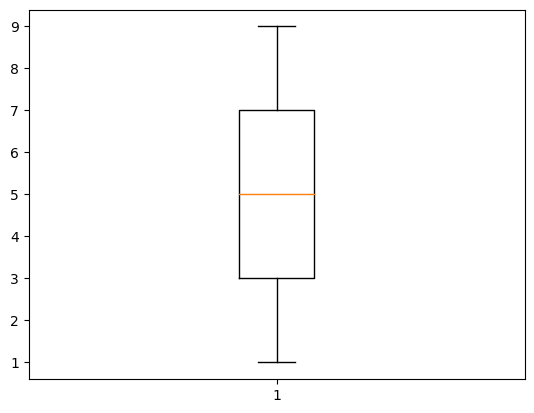

In [14]:
# Boxplot
import matplotlib.pyplot as plt
plt.boxplot(x)
plt.show()

## 4 Descriptive statistics with pandas.DataFrame


In the exploration stage, you may want to display numerical measures for each variable. To do this, you can use the `DataFrame.describe()` function.

In [15]:
!pip install wooldridge # You do not need to reinstall wooldridge if you are running Python locally

In [16]:
import wooldridge as woo
df = woo.data("wage1")

In [17]:
import pandas as pd
df.describe().round(2)

,wage,educ,exper,tenure,nonwhite,female,married,numdep,smsa,northcen,...,trcommpu,trade,services,profserv,profocc,clerocc,servocc,lwage,expersq,tenursq
count,526.00,526.00,526.00,526.00,526.0,526.00,526.00,526.00,526.00,526.00,...,526.00,526.00,526.0,526.00,526.00,526.00,526.00,526.00,526.00,526.00
mean,5.90,12.56,17.02,5.10,0.1,0.48,0.61,1.04,0.72,0.25,...,0.04,0.29,0.1,0.26,0.37,0.17,0.14,1.62,473.44,78.15
std,3.69,2.77,13.57,7.22,0.3,0.50,0.49,1.26,0.45,0.43,...,0.20,0.45,0.3,0.44,0.48,0.37,0.35,0.53,616.04,199.43
min,0.53,0.00,1.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.0,0.00,0.00,0.00,0.00,-0.63,1.00,0.00
25%,3.33,12.00,5.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.0,0.00,0.00,0.00,0.00,1.20,25.00,0.00
50%,4.65,12.00,13.50,2.00,0.0,0.00,1.00,1.00,1.00,0.00,...,0.00,0.00,0.0,0.00,0.00,0.00,0.00,1.54,182.50,4.00
75%,6.88,14.00,26.00,7.00,0.0,1.00,1.00,2.00,1.00,0.75,...,0.00,1.00,0.0,1.00,1.00,0.00,0.00,1.93,676.00,49.00
max,24.98,18.00,51.00,44.00,1.0,1.00,1.00,6.00,1.00,1.00,...,1.00,1.00,1.0,1.00,1.00,1.00,1.00,3.22,2601.00,1936.00


An alternative approach is to use the following DataFrame functions designed for descriptive analysis.
 - df.mean()
 - df.median()
 - df.quantile()
 - df.mode()
 - df.var()
 - df.std()
 - df.skew()
 - df.kurt()

You can even draw box plot for multiple variables.

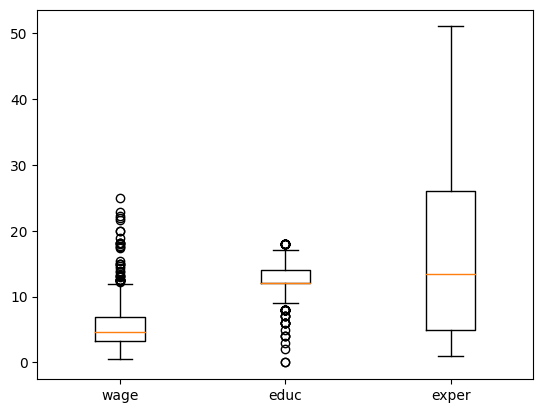

In [18]:
plt.boxplot(df[["wage","educ","exper"]], labels=["wage","educ","exper"])
plt.show()

## 5 Association between two variables

### 5.1 Formula

### Covariance
For a sample of size n with observations $(x_1,y_1),...,(x_n,y_n)$, the sample covariance is defined as follows:
$$s_{xy}=\frac{\sum(x_i-\bar{x})(y_i-\bar{y})}{n-1}$$

This formula pairs each $x_i$ with a $y_i$. We then sum the products obtained by multiplying the deviation of each $x_i$ from its sample mean by the deviation of the corresponding $y_i$ from its sample mean. This sum is then divided by $n-1$ to obtain an *unbiased* statistic.

### Pearson Correlation Coefficient
$$r_{xy}=\frac{s_{xy}}{s_xs_y}$$

Pearson correlation normalized covariance so that the result is in the range of $[-1,1]$. It represent the linear relationship between two variables, and a larger positive number indicates stronger positive relationship.

Note taht covariance and pearson correlation only captures **linear relationship** and does not work well on nonlinear relationships. As an example,

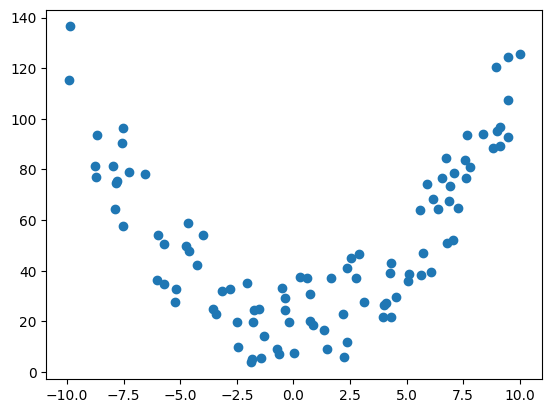

In [19]:
# generate 100 random numbers uniformly distributed on [0,10)
x = 20*np.random.random(100)-10
# Let y be x^2
y = x**2+np.random.random(100)*40
# Let's plot the distribution
plt.scatter(x=x,y=y)
plt.show()

In [20]:
# covariance between x and y
np.cov(x,y, ddof=1)

array([[  32.2276028 ,   29.38765141],
       [  29.38765141, 1020.78005181]])

In [21]:
# Pearson correlation between x and y
np.corrcoef(x,y, ddof=1) # ddof does not change pearson correlation

<ipython-input-21-578a5e74f487>:2: DeprecationWarning: bias and ddof have no effect and are deprecated
  np.corrcoef(x,y, ddof=1) # ddof does not change pearson correlation


array([[1.        , 0.16202603],
       [0.16202603, 1.        ]])

### 5.2 DataFrame Implementation

Covariance and correlation are computed for two variables or a pair of variable. Therefore, instead of working with a *Series* or *List*, we will use a *DataFrame*.

In [22]:
# here we show how to create a new dataframe from known data entries
df=pd.DataFrame({"x":[1,2,3,4,5], "y":[0.3,0.45,0.3,0.5,0.7]})

# cov
df.cov(ddof=1)

,x,y
x,2.5000,0.2125
y,0.2125,0.0275


In [23]:
#corr
df.corr()

,x,y
x,1.000000,0.810443
y,0.810443,1.000000


**Exercise** \

Compute the correlation matrix of the following variables in the wage1 data: *wage*, *educ*, *exper*.

## 6 Probability

### 6.1 Scipy.stats
When it comes to  probability calculation, we can use the **scipy** module. [scipy.stats](https://docs.scipy.org/doc/scipy/tutorial/stats.html) provides useful tools for common probability distributions. This include the computation of Probability Density (Mass for discrete distributions) Function (PD(M)F), Cumulative Distribution Function (CDF), Survival Function, Hazard Function, and more ...

As an example, let X denotes the number of white balls we obtain from an experienment where we draw 10 balls with replacement from an urn of 20 white balls and 80 black balls.

X satisfies the Binomial distribution, with parameters n=10 and p=20%.

In [24]:
from scipy import stats
n=10
p=0.2

# probability of getting exactly 2 white balls
stats.binom.pmf(2,n,p)

0.30198988800000004

In [25]:
# probability of getting at most 3 white balls
stats.binom.cdf(3,n,p)

0.8791261183999999

In [26]:
# probability of getting at least 4 white ball
stats.binom.sf(4-1,n,p)

0.12087388160000007

In [27]:
# moments of this distribution (mean, variance, skewness, kurtosis)
stats.binom.stats(n,p,moments='mvsk')

(2.0, 1.6, 0.4743416490252569, 0.024999999999999883)

### 6.2 Visualization

We can also use the **matplotlib.pyplot** module to visualize these probability distributions.

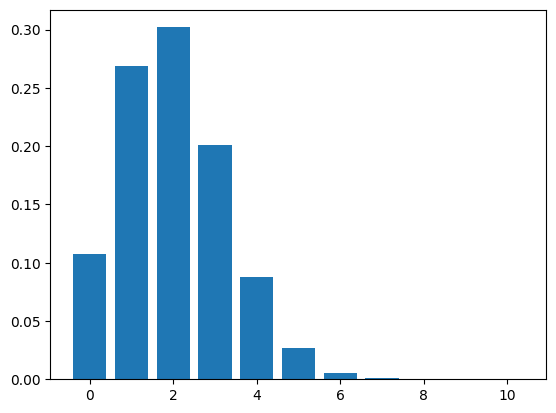

In [28]:
import matplotlib.pyplot as plt

# values for k
k = range(n+1)

# pmf for k
pmf = stats.binom.pmf(k,n,p)

# use line plot for pmf
plt.bar(x=k,height=pmf)
plt.show()

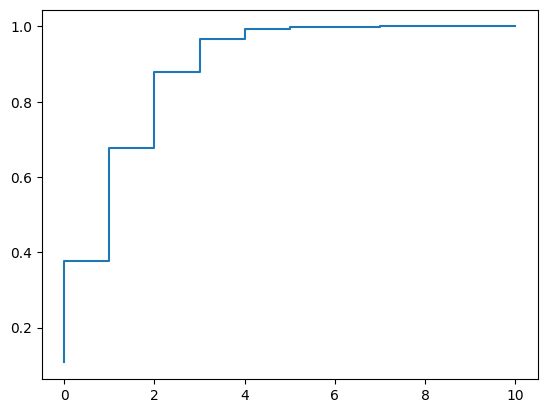

In [29]:
# cdf for k
cdf = stats.binom.cdf(k,n,p)

# create a step plot for cdf
plt.step(k,cdf)
plt.show()

<Axes: >

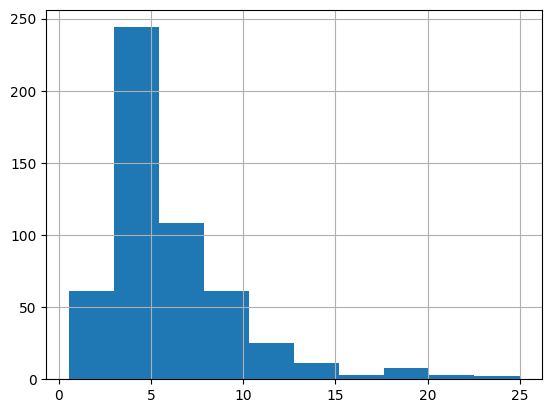

In [30]:
# empirical distribution from data
df = woo.data("wage1")

# histogram (frequency)
df["wage"].hist()

<Axes: >

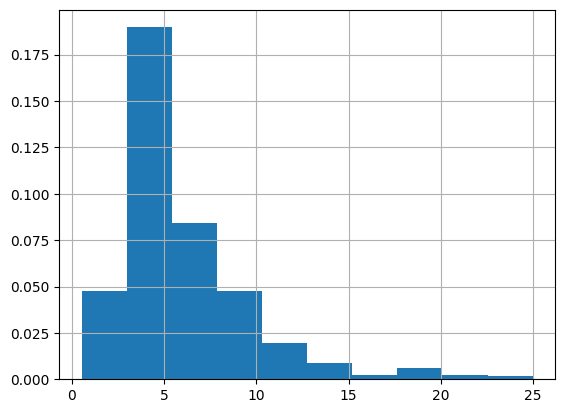

In [31]:
# histogram (density)
df["wage"].hist(density=True)

<Axes: >

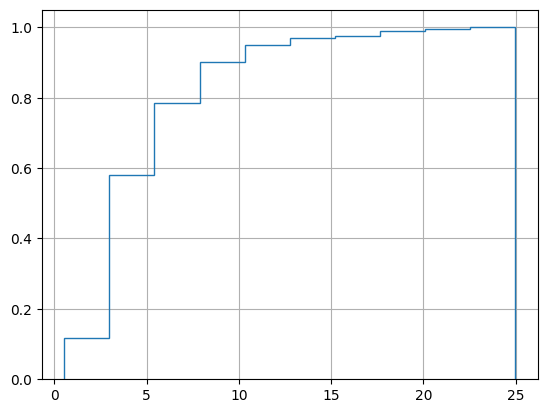

In [32]:
# empirical cdf
df["wage"].hist(density=True, cumulative=True, histtype="step")

### 6.3 Random Draws from probability distribution

Distribution objects from the scipy.stats module can also facilitate random draws. For example, the following codes draw 10 random observations from the previous binomial distribution.

In [33]:
stats.binom.rvs(n,p,size=10)

array([2, 1, 4, 1, 0, 1, 1, 2, 3, 1])

In [34]:
# or alternatively, initialize the distribution with parameters
stats.binom(n,p).rvs(10)

array([1, 2, 4, 1, 1, 1, 3, 4, 1, 0])